Equilibration completed for 40000 samples.
C(0) = 0.995727
<p0^2> = 0.995727  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 9.4107e-01


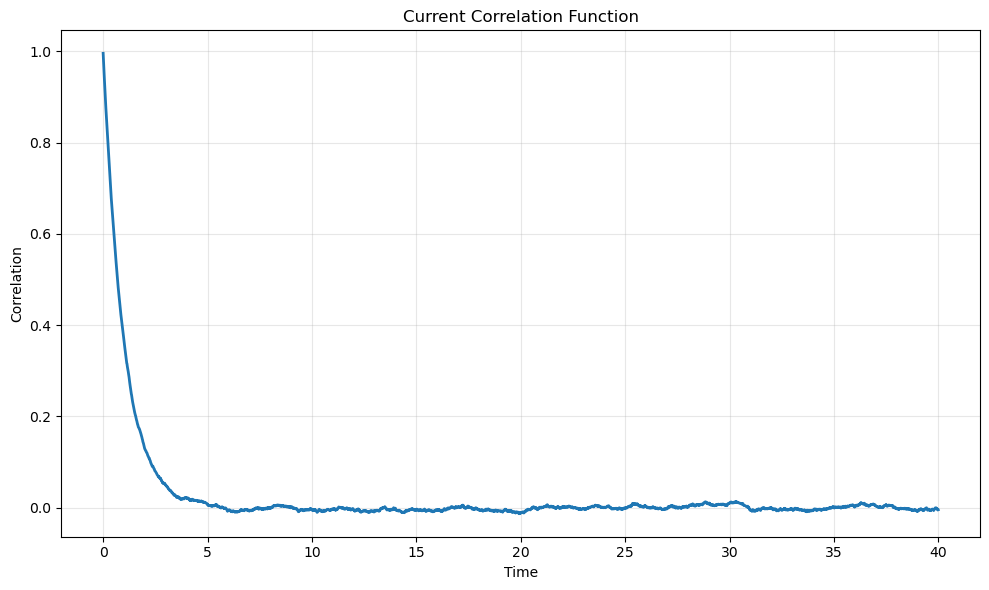

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = rho q p /m

def dHdq(q, p):
    return 0  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 1  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

Equilibration completed for 50000 samples.
C(0) = 0.997829
<p0^2> = 0.997858  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): -4.2328e-03


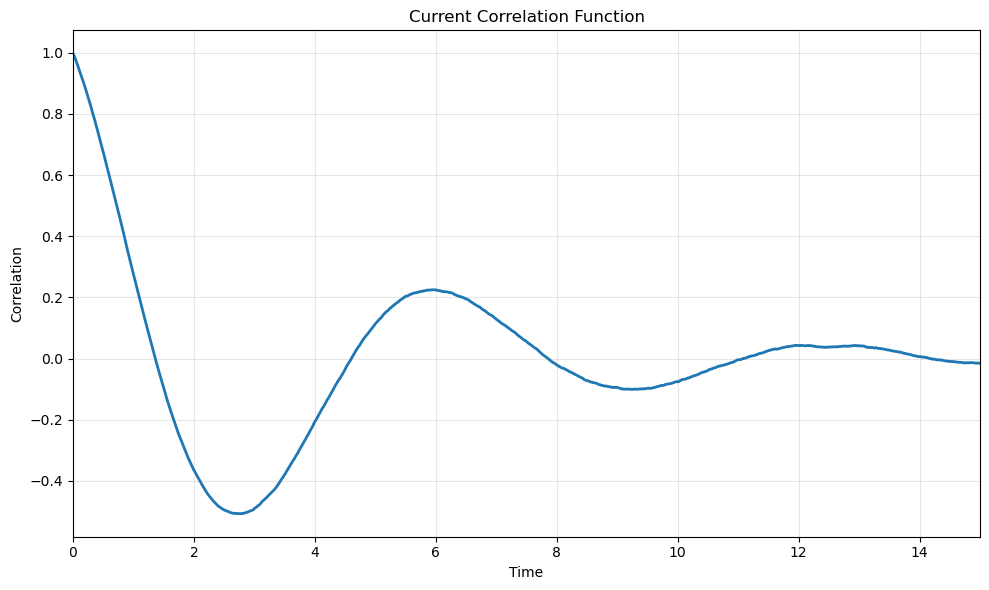

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = 

def dHdq(q, p):
    return q  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 0.5  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 15000  # Number of steps to simulate
num_samples = 50000  # Number of samples for correlation
system = LangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.xlim(0, 15)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

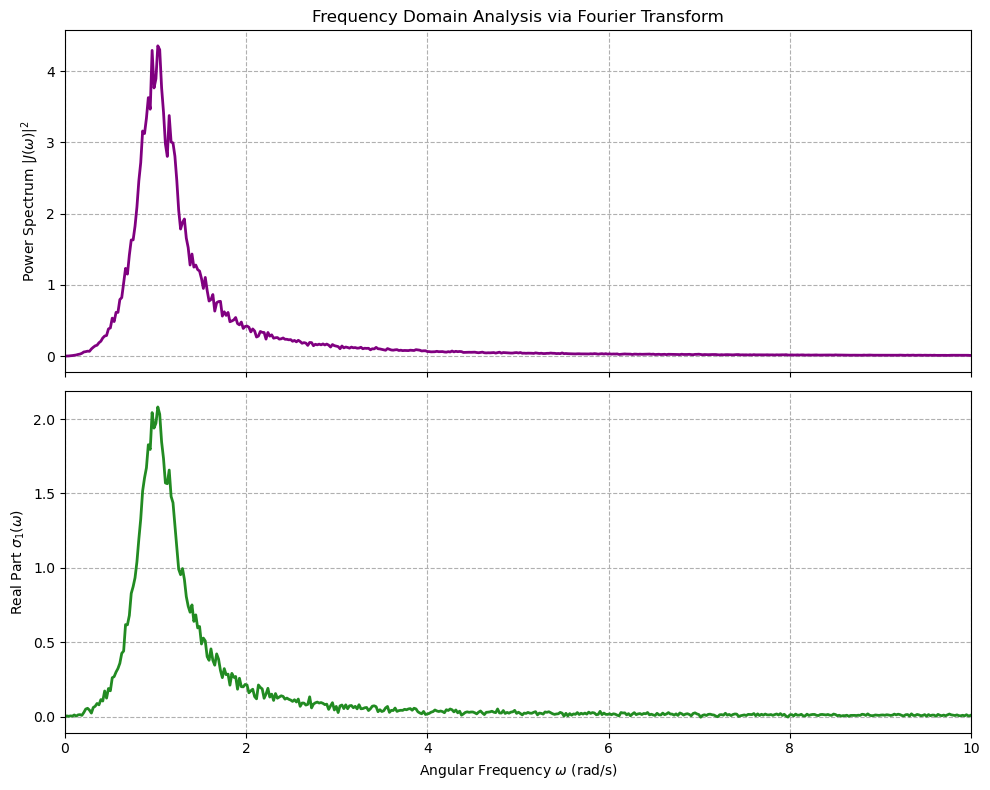

In [35]:
# --- 1. 因果律を満たすために、後ろ半分をゼロで埋める (Zero Padding) ---
# これにより、プログラムに「t=num_steps 以降、および周期性の裏返しとしての t<0 は完全に0である」
# という因果律の境界条件を教え込むことができます。
j_causal = np.concatenate([j_correlation, np.zeros(num_steps)])

# 全要素数は 2 * num_steps になります
N_total = len(j_causal)

# --- 2. 周波数軸の作成 ---
frequencies = np.fft.rfftfreq(N_total, d=dt)
omega = 2 * np.pi * frequencies

# --- 3. フーリエ変換を実行 ---
# dt を掛けて積分形式にします。
# これにより、j_fft は「実部」と「虚部」を両方持った正しい複素数になります。
j_fft = np.fft.rfft(j_causal) * dt

# --- 4. sigma(omega) の導出 ---
# 因果律を満たした変換なので、実部も虚部も両方とも物理的に正しい意味を持ちます！
sigma_omega = j_fft / (k_B * T)

sigma_1_omega = np.real(sigma_omega)  # 🌟 実部：オーム抵抗成分（エネルギー散乱）
sigma_2_omega = -np.imag(sigma_omega) # 🌟 虚部：リアクタンス成分（ポテンシャルのバネ）

# パワースペクトル（ゆらぎのエネルギー密度）
power_spectrum = np.abs(j_fft)**2

# 参考：交流電気伝導度の実部 sigma_1(omega) は、FFTした結果の実部を k_B * T で割ったもの
sigma_1_omega = np.real(j_fft) / (k_B * T)

# --- 4. 結果のプロット ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# 上段：純粋なパワースペクトル |J(omega)|^2
ax1.plot(omega, power_spectrum, color='purple', linewidth=2)
ax1.set_ylabel('Power Spectrum $|J(\\omega)|^2$')
ax1.set_title('Frequency Domain Analysis via Fourier Transform')
ax1.grid(True, linestyle='--')
ax1.set_xlim(0, 10)  # X軸の表示範囲を制限（必要に応じて調整してください）

# 下段：光学伝導度（交流伝導度）の実部 sigma_1(omega)
ax2.plot(omega, sigma_1_omega, color='forestgreen', linewidth=2)
ax2.set_xlabel('Angular Frequency $\\omega$ (rad/s)')
ax2.set_ylabel('Real Part $\\sigma_1(\\omega)$')
ax2.grid(True, linestyle='--')
ax2.set_xlim(0, 10)

# 10 Hz（omega = 2 * pi * 10 = 62.8）の周辺が見やすいように、X軸の表示範囲を制限
#（必要に応じて調整してください）
ax2.set_xlim(0, 10) 

plt.tight_layout()
plt.show()

Equilibration completed for 40000 samples.
C(0) = 0.993938
<p0^2> = 0.994016  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 4.8499e-01


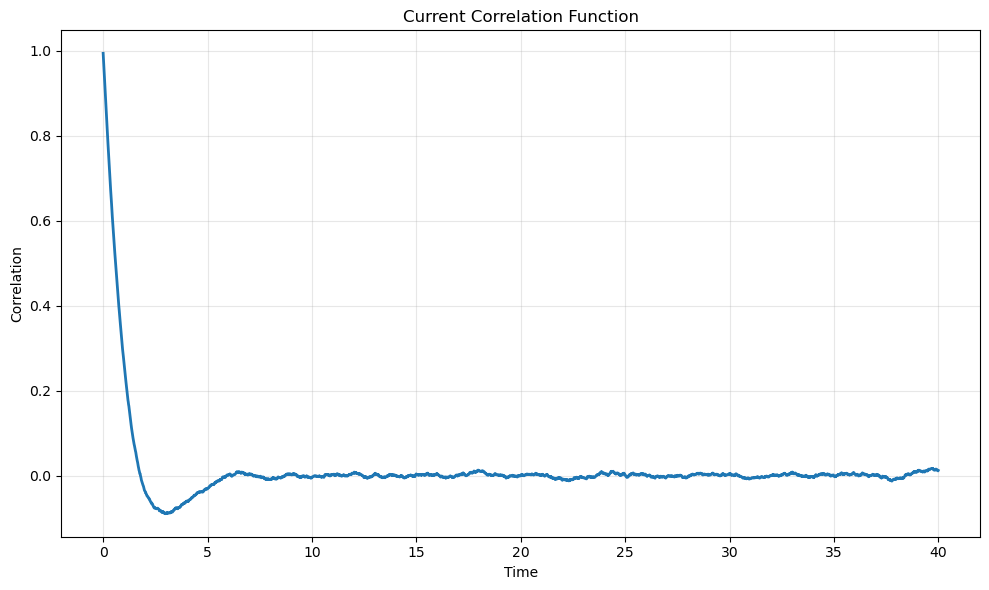

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = 

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

# Energy and temperature in k_B*T scaling (dimensionless)
# k_B*T is the fundamental energy unit
k_B = 1.0  # Boltzmann constant (dimensionless in k_B*T scaling)
T = 1.0    # Temperature (dimensionless in k_B*T scaling)

# Physical parameters
gamma = 1  # Friction coefficient (scaled appropriately)
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step (in appropriate units)

def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)  


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

Equilibration completed for 40000 samples.
C(0) = 1.004847
<p0^2> = 1.004871  (theoretical: 1.0)
C(0)/C_max ratio: 1.000
Integrated correlation (conductivity): 5.3837e-01


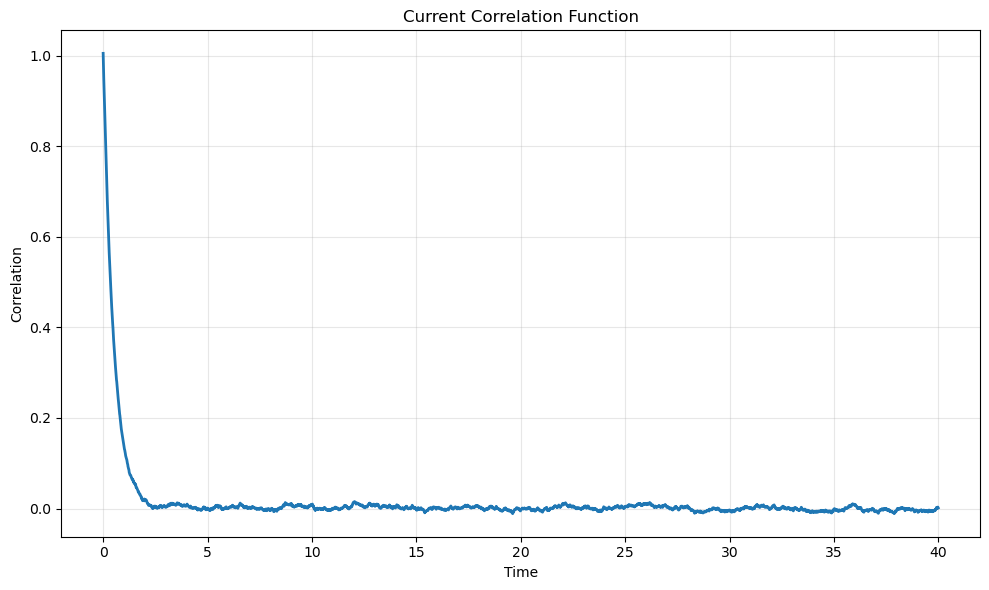

In [ ]:
gamma = 2  # Friction coefficient (scaled appropriately)
def sample_initial_conditions(num_samples):
    # In k_B*T scaling: standard deviation = sqrt(k_B*T) = 1
    q_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, 1.0) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    print(f"Equilibration completed for {num_samples} samples.")
    return q_tempo, p_tempo

num_steps = 4000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples) 

j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)

# Debug: Check initial correlation value and statistics
C0 = j_correlation[0]
p0_sq = np.mean(p0**2)
print(f"C(0) = {C0:.6f}")
print(f"<p0^2> = {p0_sq:.6f}  (theoretical: 1.0)")
print(f"C(0)/C_max ratio: {C0/np.max(np.abs(j_correlation)):.3f}")

# Apply time-dependent damping correction if needed

integrated_value = np.trapezoid(j_correlation, dx=dt)
print(f"Integrated correlation (conductivity): {integrated_value:.4e}")

times = np.arange(0, num_steps*dt, dt)
plt.figure(figsize=(10, 6))
plt.plot(times, j_correlation, linewidth=2)
plt.title('Current Correlation Function')
plt.xlabel('Time')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
plt.show()

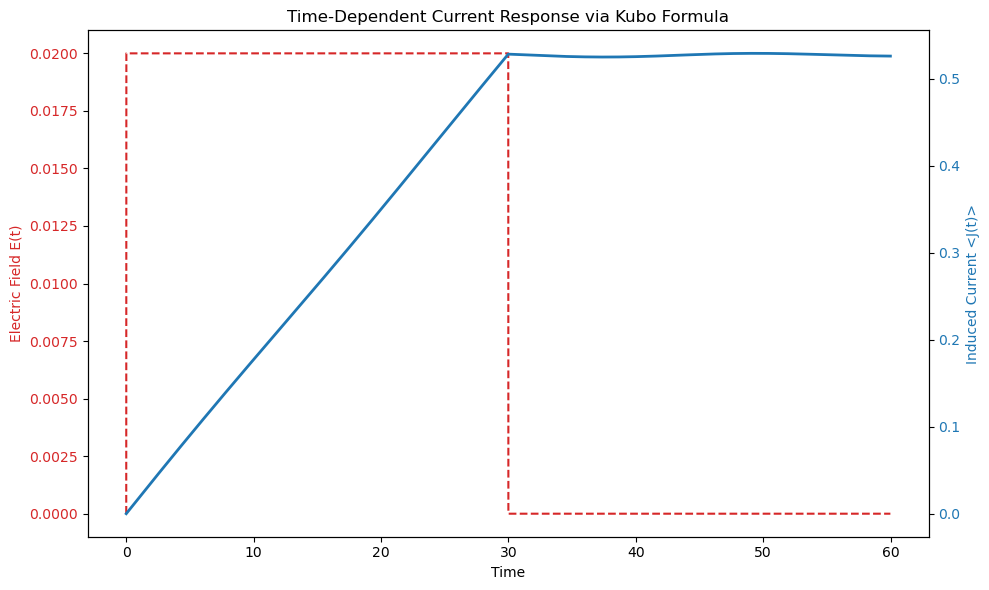

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return 0.1*np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 0  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.01  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    if  0 < t < 30:
        return 0.02  
    else:
        return 0 

num_steps = 6000  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)


plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()

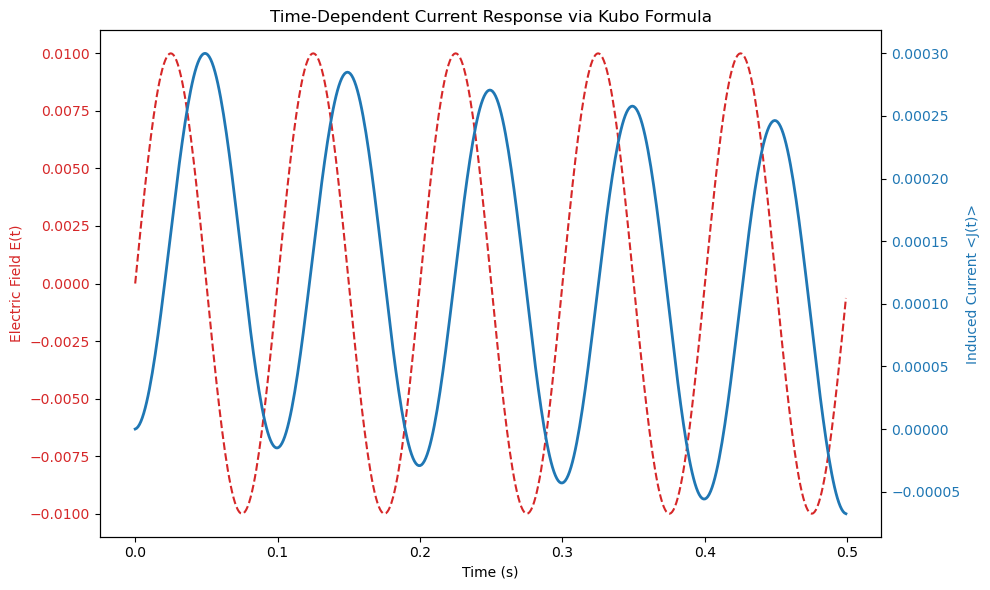

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return np.sin(q)  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 1  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.001  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    return 0.01*np.sin(2 * np.pi * 10 * t)  # Example: sinusoidal electric field with frequency 10 Hz

num_steps = 500  # Number of steps to simulate
num_samples = 40000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()

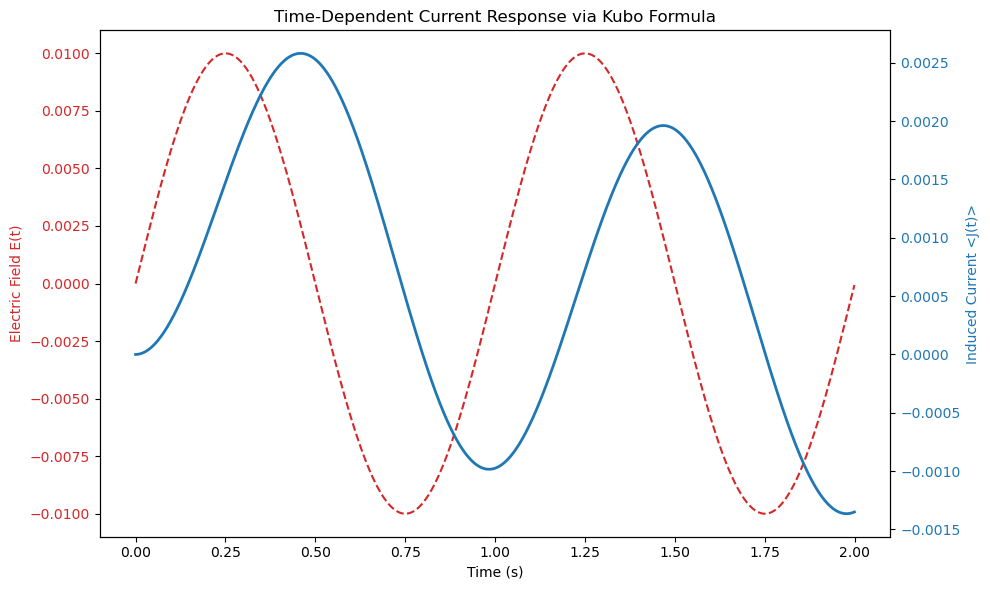

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from Langevin import LangevinSystem, PeriodicLangevinSystem
from correlation_func import time_evolution_correlation


def current_A(q, p):
    return  p  # J = p

def dHdq(q, p):
    return 0  # potential energy gradient
def dHdp(q, p):
    return p  # kinetic energy gradient

T = 1  # Temperature in Kelvin
k_B = 1  # Boltzmann constant in J/K
gamma = 1  # Friction coefficient
period = 2 * np.pi  # Period for periodic boundary conditions
dt = 0.001  # Time step in seconds

def sample_initial_conditions(num_samples):
    q_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    p_tempo = np.array([np.random.normal(0, np.sqrt(k_B * T)) for _ in range(num_samples)])
    for _ in range(3000):  # Equilibration steps
        q_tempo, p_tempo = system.step(q_tempo, p_tempo, dt)
    return q_tempo, p_tempo

def electric_field(t):
    return 0.01*np.sin(2 * np.pi * t)  # Example: sinusoidal electric field with frequency 10 Hz

num_steps = 2000  # Number of steps to simulate
num_samples = 20000  # Number of samples for correlation
system = PeriodicLangevinSystem(dHdq, dHdp, gamma=gamma, k_B=k_B, T=T, period=period)
q0, p0 = sample_initial_conditions(num_samples)


j_correlation = time_evolution_correlation(system, current_A, q0, p0, dt, num_steps)


# --- 2. タイムラインと電場 E(t) の配列を作成 ---
times = np.arange(0, num_steps * dt, dt)
E_t = np.array([electric_field(t) for t in times])

# --- 3. 久保公式に基づく応答関数 σ(t) の作成 ---
# 線形応答理論では、相関関数を k_B * T で割る必要があります
response_function = j_correlation / (k_B * T)

# --- 4. 畳み込み積分の実行 ---
# np.convolve で -inf から t までの積分を一括計算します
# dt を掛けることで、単なる配列の和ではなく「積分」になります
J_t = np.convolve(E_t, response_function, mode='full')[:num_steps] * dt 

# --- 5. プロット（原因である電場と、結果である電流を左右の軸で比較） ---
fig, ax1 = plt.subplots(figsize=(10, 6))

# 左軸：電場 E(t) （赤の破線）
color = 'tab:red'
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Electric Field E(t)', color=color)
ax1.plot(times, E_t, color=color, linestyle='--', label='Electric Field')
ax1.tick_params(axis='y', labelcolor=color)  # 電場のON/OFFを見やすくするための調整

# 右軸：電流応答 <J(t)> （青の実線）
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Induced Current <J(t)>', color=color)
ax2.plot(times, J_t, color=color, linewidth=2, label='Current Response')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Time-Dependent Current Response via Kubo Formula')
fig.tight_layout()
plt.show()

In [ ]:
from Langevin import InteractingParticles2D
import numpy as np
import matplotlib.pyplot as plt

# --- シミュレーションの設定 ---
num_particles = 1024    # 粒子数
box_size = 100.0       # 箱の大きさ（-5.0 〜 5.0）
gamma = 0.5           # 摩擦（ダンピング）
dt = 0.01             # タイムステップ（急激な反発があるため小さめに設定）
steps = 500           # シミュレーションのステップ数

# インスタンスの作成
sim = InteractingParticles2D(
    num_particles=num_particles, 
    box_size=box_size, 
    gamma=gamma, 
    epsilon=1.0, 
    sigma=1.0, 
    T=1.0
)

# --- 初期状態の設定 ---
# 重なりを防ぐため、ランダムではなく綺麗な格子状に初期配置してみます
grid_dim = int(np.ceil(np.sqrt(num_particles)))
x = np.linspace(-box_size/3, box_size/3, grid_dim)
y = np.linspace(-box_size/3, box_size/3, grid_dim)
X, Y = np.meshgrid(x, y)
q_init = np.stack([X.flatten(), Y.flatten()], axis=1)[:num_particles]

# 1次元配列(2*N,)に平坦化
q = q_init.flatten()
# 初期運動量はマクスウェル・ボルツマン分布（標準正規分布）からサンプリング
p = np.random.normal(0, np.sqrt(sim.mass * sim.T), size=2 * num_particles)

# --- シミュレーションループ ---
steps_list = []
ver_p_list = []
trajectory = []

for step in range(steps):
    q, p = sim.step(q, p, dt)
    
    # 解析や描画のために、(N, 2)の形に戻して保存
    trajectory.append(q.reshape((num_particles, 2)).copy())
    steps_list.append(step)
    ver_p_list.append(np.var(p))

    if step % 100 == 0:
        print(f"Step {step}/{steps} completed.")

trajectory = np.array(trajectory)
plt.figure(figsize=(10, 6))
plt.plot(steps_list, ver_p_list, linewidth=2)